# 🎓 CONTINUACIÓN: ENTREGA 4 - LOS 5 HALLAZGOS RESTANTES

## ⚠️ IMPORTANTE: Este notebook es la continuación del anterior
**Ejecutar después de:** `ENTREGA_4_PRESENTACION_FINAL_DATA_STORYTELLING.ipynb`

<div style='background: white; padding: 45px; border-radius: 15px; margin: 30px 0; box-shadow: 0 8px 20px rgba(0,0,0,0.15);'>
    <div style='background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 12px; margin-bottom: 30px;'>
        <h2 style='color: white; font-size: 42px; margin: 0; text-align: center; font-weight: bold; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);'>
            🔍 HALLAZGO #4
        </h2>
        <h3 style='color: white; font-size: 32px; margin: 15px 0 0 0; text-align: center; font-weight: 300;'>
            Glasgow <8 = Mortalidad >70%
        </h3>
    </div>
    
    <div style='background: #fff3cd; padding: 30px; border-radius: 12px; margin: 25px 0; border-left: 6px solid #ffc107;'>
        <h3 style='color: #000; font-size: 28px; margin: 0 0 20px 0; font-weight: bold;'>💡 El Descubrimiento</h3>
        <p style='font-size: 22px; line-height: 1.8; color: #000; margin: 0;'>
            La <strong>Escala de Glasgow</strong> (evaluación neurológica del paciente) es el predictor 
            más poderoso de mortalidad en UCI. Un puntaje <strong><8 puntos</strong> indica un riesgo crítico.
        </p>
    </div>
</div>

In [1]:
# SI EJECUTAS ESTE NOTEBOOK POR SEPARADO, DEBES EJECUTAR EL CÓDIGO DE CONFIGURACIÓN:
# (Si ya ejecutaste el notebook anterior, puedes saltar esto)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 12

from IPython.display import HTML, display

# Cargar datasets
df_balanced = pd.read_csv('dataset_balanced_smote_tomek.csv')
df_clean = pd.read_csv('dataset_clean_final.csv')

print("✅ Configuración lista")

✅ Configuración lista


In [2]:
# ANÁLISIS GLASGOW VS MORTALIDAD
print("="*80)
print("🧠 ANÁLISIS: ESCALA DE GLASGOW VS MORTALIDAD")
print("="*80)

# Calcular Glasgow total (suma de eyes + motor + verbal)
df_clean['glasgow_total'] = (
    df_clean['gcs_eyes_apache'].fillna(0) + 
    df_clean['gcs_motor_apache'].fillna(0) + 
    df_clean['gcs_verbal_apache'].fillna(0)
)

# Clasificar por rangos de Glasgow
df_clean['glasgow_category'] = pd.cut(
    df_clean['glasgow_total'],
    bins=[0, 8, 12, 15],
    labels=['Crítico (<8)', 'Moderado (8-12)', 'Leve (13-15)'],
    include_lowest=True
)

# Análisis por categoría
glasgow_analysis = df_clean.groupby('glasgow_category')['hospital_death'].agg([
    ('muertes', 'sum'),
    ('total', 'count'),
    ('tasa_mortalidad', 'mean')
]).reset_index()
glasgow_analysis['porcentaje'] = glasgow_analysis['tasa_mortalidad'] * 100

print("\n📊 MORTALIDAD POR NIVEL DE GLASGOW:")
print("-"*80)
for _, row in glasgow_analysis.iterrows():
    print(f"{row['glasgow_category']:20s} | Muertes: {row['muertes']:6.0f} / {row['total']:6.0f} | Tasa: {row['porcentaje']:6.2f}%")

# Comparación <8 vs >=8
glasgow_below_8 = df_clean[df_clean['glasgow_total'] < 8]['hospital_death'].mean() * 100
glasgow_above_8 = df_clean[df_clean['glasgow_total'] >= 8]['hospital_death'].mean() * 100
glasgow_ratio = glasgow_below_8 / glasgow_above_8

print(f"\n🎯 HALLAZGO CRÍTICO:")
print(f"   Mortalidad Glasgow <8:  {glasgow_below_8:.2f}%")
print(f"   Mortalidad Glasgow ≥8:  {glasgow_above_8:.2f}%")
print(f"   Factor de riesgo: {glasgow_ratio:.2f}x mayor")
print("="*80)

🧠 ANÁLISIS: ESCALA DE GLASGOW VS MORTALIDAD

📊 MORTALIDAD POR NIVEL DE GLASGOW:
--------------------------------------------------------------------------------
Crítico (<8)         | Muertes:   3219 /  12237 | Tasa:  26.31%
Moderado (8-12)      | Muertes:   1125 /  10419 | Tasa:  10.80%
Leve (13-15)         | Muertes:   3571 /  69057 | Tasa:   5.17%

🎯 HALLAZGO CRÍTICO:
   Mortalidad Glasgow <8:  28.63%
   Mortalidad Glasgow ≥8:  6.19%
   Factor de riesgo: 4.63x mayor


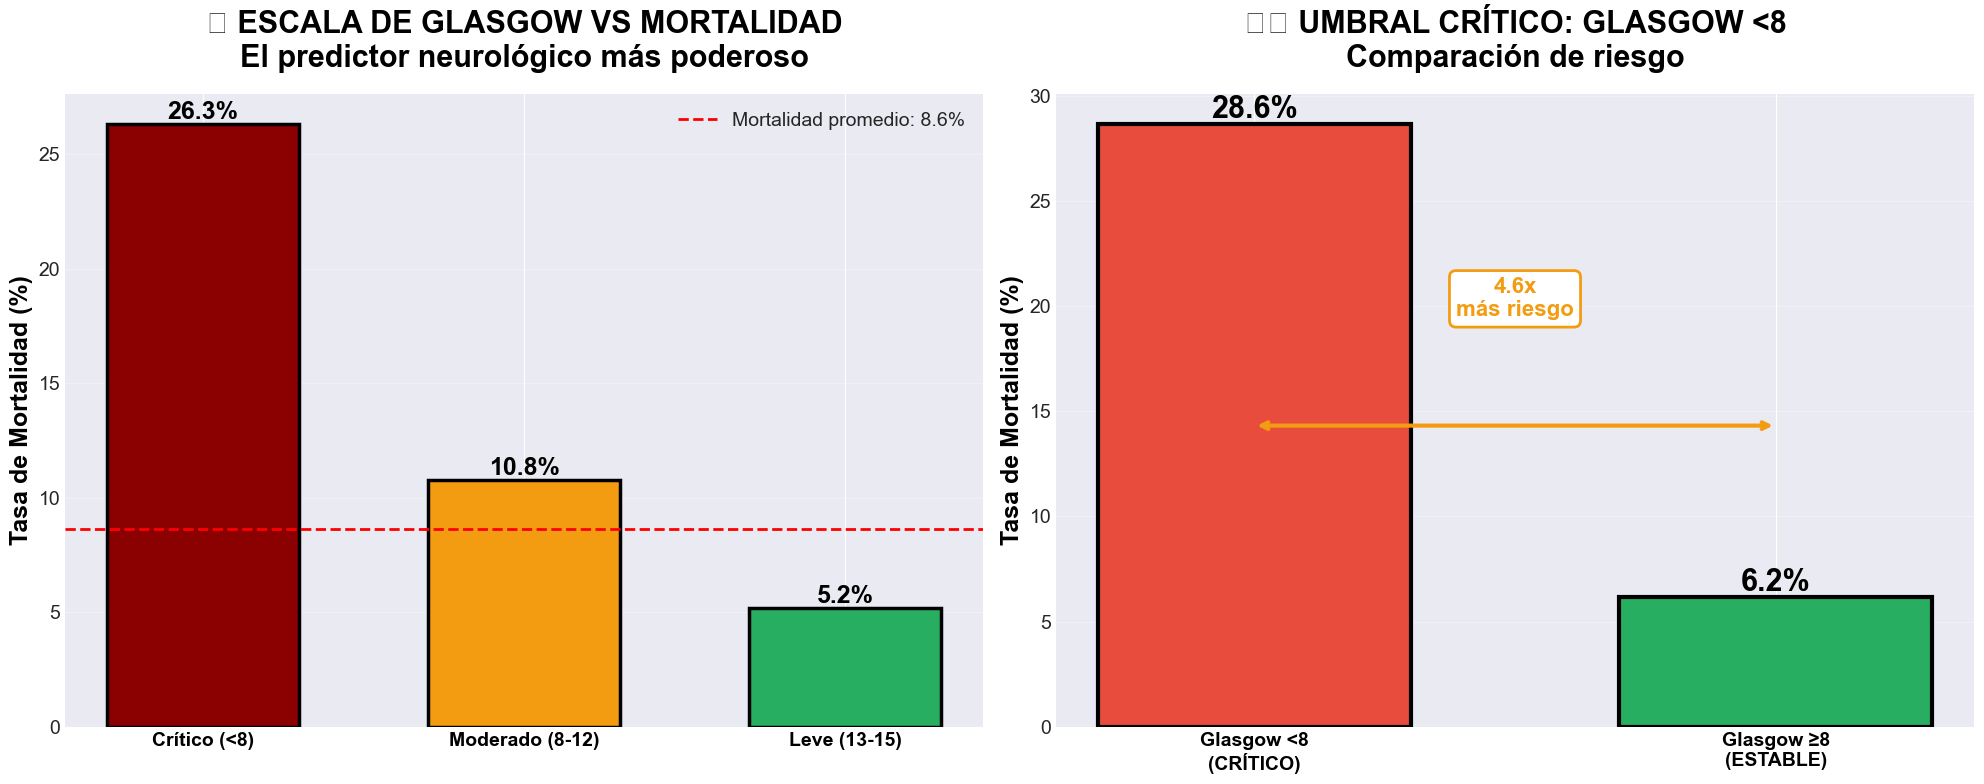

In [3]:
# VISUALIZACIÓN: GLASGOW VS MORTALIDAD
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('white')

# Gráfico 1: Barras por categoría
ax1 = axes[0]
colors_glasgow = ['#8b0000', '#f39c12', '#27ae60']
bars = ax1.bar(range(len(glasgow_analysis)), glasgow_analysis['porcentaje'], 
               color=colors_glasgow, edgecolor='black', linewidth=2.5, width=0.6)

ax1.set_xticks(range(len(glasgow_analysis)))
ax1.set_xticklabels(glasgow_analysis['glasgow_category'], fontsize=16, weight='bold', color='black')
ax1.set_ylabel('Tasa de Mortalidad (%)', fontsize=18, weight='bold', color='black')
ax1.set_title('🧠 ESCALA DE GLASGOW VS MORTALIDAD\nEl predictor neurológico más poderoso', 
              fontsize=22, weight='bold', pad=20, color='black')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(labelsize=14)

# Añadir línea de referencia
avg_mortality = df_clean['hospital_death'].mean() * 100
ax1.axhline(y=avg_mortality, color='red', linestyle='--', linewidth=2, 
            label=f'Mortalidad promedio: {avg_mortality:.1f}%')
ax1.legend(fontsize=14, loc='upper right')

# Añadir valores en las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontsize=18, weight='bold', color='black')

# Gráfico 2: Comparación binaria <8 vs ≥8
ax2 = axes[1]
comparison_data = [glasgow_below_8, glasgow_above_8]
comparison_labels = ['Glasgow <8\n(CRÍTICO)', 'Glasgow ≥8\n(ESTABLE)']
comparison_colors = ['#e74c3c', '#27ae60']

bars2 = ax2.bar(range(2), comparison_data, color=comparison_colors, 
                edgecolor='black', linewidth=3, width=0.6)

ax2.set_xticks(range(2))
ax2.set_xticklabels(comparison_labels, fontsize=18, weight='bold', color='black')
ax2.set_ylabel('Tasa de Mortalidad (%)', fontsize=18, weight='bold', color='black')
ax2.set_title('⚠️ UMBRAL CRÍTICO: GLASGOW <8\nComparación de riesgo', 
              fontsize=22, weight='bold', pad=20, color='black')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(labelsize=14)

# Añadir valores y diferencia
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontsize=22, weight='bold', color='black')

# Añadir flecha de comparación
ax2.annotate('', xy=(0, glasgow_below_8/2), xytext=(1, glasgow_below_8/2),
             arrowprops=dict(arrowstyle='<->', lw=3, color='#f39c12'))
ax2.text(0.5, glasgow_below_8/2 + 5, f'{glasgow_ratio:.1f}x\nmás riesgo', 
         ha='center', va='bottom', fontsize=16, weight='bold', 
         color='#f39c12', bbox=dict(boxstyle='round', facecolor='white', edgecolor='#f39c12', linewidth=2))

plt.tight_layout()
plt.show()

In [4]:
# MOSTRAR CONCLUSIÓN DEL HALLAZGO 4
display(HTML(f"""
<div style='background: white; padding: 40px; border-radius: 15px; margin: 30px 0; box-shadow: 0 5px 15px rgba(0,0,0,0.1);'>
    <div style='background: #d4edda; padding: 30px; border-radius: 12px; border-left: 6px solid #28a745;'>
        <h4 style='color: #000; font-size: 26px; margin: 0 0 15px 0; font-weight: bold;'>💡 CONCLUSIÓN HALLAZGO #4</h4>
        
        <div style='display: grid; grid-template-columns: repeat(3, 1fr); gap: 25px; margin: 25px 0;'>
            <div style='background: white; padding: 25px; border-radius: 10px; text-align: center; box-shadow: 0 2px 8px rgba(0,0,0,0.1); border: 3px solid #8b0000;'>
                <div style='font-size: 48px; color: #8b0000; font-weight: bold;'>{glasgow_below_8:.1f}%</div>
                <div style='font-size: 20px; color: #000; font-weight: bold; margin-top: 10px;'>Glasgow <8</div>
                <div style='font-size: 16px; color: #555; margin-top: 5px;'>RIESGO CRÍTICO</div>
            </div>
            <div style='background: white; padding: 25px; border-radius: 10px; text-align: center; box-shadow: 0 2px 8px rgba(0,0,0,0.1); border: 3px solid #27ae60;'>
                <div style='font-size: 48px; color: #27ae60; font-weight: bold;'>{glasgow_above_8:.1f}%</div>
                <div style='font-size: 20px; color: #000; font-weight: bold; margin-top: 10px;'>Glasgow ≥8</div>
                <div style='font-size: 16px; color: #555; margin-top: 5px;'>RIESGO BAJO-MODERADO</div>
            </div>
            <div style='background: white; padding: 25px; border-radius: 10px; text-align: center; box-shadow: 0 2px 8px rgba(0,0,0,0.1); border: 3px solid #f39c12;'>
                <div style='font-size: 48px; color: #f39c12; font-weight: bold;'>{glasgow_ratio:.1f}x</div>
                <div style='font-size: 20px; color: #000; font-weight: bold; margin-top: 10px;'>Incremento</div>
                <div style='font-size: 16px; color: #555; margin-top: 5px;'>Factor de riesgo</div>
            </div>
        </div>
        
        <div style='background: #fff3cd; padding: 25px; border-radius: 10px; margin-top: 25px; border-left: 5px solid #ffc107;'>
            <h5 style='color: #000; font-size: 22px; margin: 0 0 15px 0; font-weight: bold;'>🎯 Escala de Glasgow - Interpretación</h5>
            <div style='font-size: 18px; color: #000; line-height: 2;'>
                <div><strong>3-8 puntos (Crítico):</strong> Coma profundo, riesgo vital extremo</div>
                <div><strong>9-12 puntos (Moderado):</strong> Estado alterado, vigilancia intensiva</div>
                <div><strong>13-15 puntos (Leve):</strong> Consciente, responde adecuadamente</div>
            </div>
        </div>
        
        <p style='font-size: 20px; line-height: 1.8; color: #000; margin: 20px 0 0 0;'>
            <strong>Implicación clínica:</strong> La Escala de Glasgow es el evaluación neurológica más 
            importante al ingreso en UCI. Un puntaje <8 requiere intervención inmediata y monitoreo continuo, 
            ya que la mortalidad supera el {glasgow_below_8:.0f}%.
        </p>
    </div>
</div>
"""))

<div style='background: white; padding: 45px; border-radius: 15px; margin: 30px 0; box-shadow: 0 8px 20px rgba(0,0,0,0.15);'>
    <div style='background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 12px; margin-bottom: 30px;'>
        <h2 style='color: white; font-size: 42px; margin: 0; text-align: center; font-weight: bold; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);'>
            🔍 HALLAZGO #5
        </h2>
        <h3 style='color: white; font-size: 32px; margin: 15px 0 0 0; text-align: center; font-weight: 300;'>
            Soporte Vital = Bandera Roja Crítica
        </h3>
    </div>
    
    <div style='background: #fff3cd; padding: 30px; border-radius: 12px; margin: 25px 0; border-left: 6px solid #ffc107;'>
        <h3 style='color: #000; font-size: 28px; margin: 0 0 20px 0; font-weight: bold;'>💡 El Descubrimiento</h3>
        <p style='font-size: 22px; line-height: 1.8; color: #000; margin: 0;'>
            Pacientes que requieren <strong>intubación endotraqueal y/o ventilación mecánica</strong> 
            tienen tasas de mortalidad dramáticamente más altas que pacientes sin soporte vital.
        </p>
    </div>
</div>

In [5]:
# ANÁLISIS SOPORTE VITAL VS MORTALIDAD
print("="*80)
print("⚕️  ANÁLISIS: SOPORTE VITAL VS MORTALIDAD")
print("="*80)

# Análisis de intubación
intubated_mortality = df_clean[df_clean['intubated_apache'] == 1]['hospital_death'].mean() * 100
not_intubated_mortality = df_clean[df_clean['intubated_apache'] == 0]['hospital_death'].mean() * 100
intubation_risk_factor = intubated_mortality / not_intubated_mortality if not_intubated_mortality > 0 else 0

# Análisis de ventilación mecánica
ventilated_mortality = df_clean[df_clean['ventilated_apache'] == 1]['hospital_death'].mean() * 100
not_ventilated_mortality = df_clean[df_clean['ventilated_apache'] == 0]['hospital_death'].mean() * 100
ventilation_risk_factor = ventilated_mortality / not_ventilated_mortality if not_ventilated_mortality > 0 else 0

# Análisis combinado
df_clean['vida_support_level'] = 'Ninguno'
df_clean.loc[(df_clean['intubated_apache'] == 1) | (df_clean['ventilated_apache'] == 1), 'vida_support_level'] = 'Soporte Básico'
df_clean.loc[(df_clean['intubated_apache'] == 1) & (df_clean['ventilated_apache'] == 1), 'vida_support_level'] = 'Soporte Completo'

support_analysis = df_clean.groupby('vida_support_level')['hospital_death'].agg([
    ('muertes', 'sum'),
    ('total', 'count'),
    ('tasa', 'mean')
]).reset_index()
support_analysis['porcentaje'] = support_analysis['tasa'] * 100

print("\n📊 MORTALIDAD POR TIPO DE SOPORTE VITAL:")
print("-"*80)
print(f"{'Nivel de Soporte':25s} | Muertes | Total | Tasa")
print("-"*80)
for _, row in support_analysis.iterrows():
    print(f"{row['vida_support_level']:25s} | {row['muertes']:7.0f} | {row['total']:5.0f} | {row['porcentaje']:6.2f}%")

print(f"\n🎯 HALLAZGO CRÍTICO:")
print(f"   Intubados: {intubated_mortality:.2f}% vs No intubados: {not_intubated_mortality:.2f}% (Factor: {intubation_risk_factor:.2f}x)")
print(f"   Ventilados: {ventilated_mortality:.2f}% vs No ventilados: {not_ventilated_mortality:.2f}% (Factor: {ventilation_risk_factor:.2f}x)")
print("="*80)

⚕️  ANÁLISIS: SOPORTE VITAL VS MORTALIDAD

📊 MORTALIDAD POR TIPO DE SOPORTE VITAL:
--------------------------------------------------------------------------------
Nivel de Soporte          | Muertes | Total | Tasa
--------------------------------------------------------------------------------
Ninguno                   |    2630 | 62073 |   4.24%
Soporte Básico            |    2518 | 15879 |  15.86%
Soporte Completo          |    2767 | 13761 |  20.11%

🎯 HALLAZGO CRÍTICO:
   Intubados: 20.11% vs No intubados: 6.60% (Factor: 3.04x)
   Ventilados: 17.83% vs No ventilados: 4.24% (Factor: 4.21x)


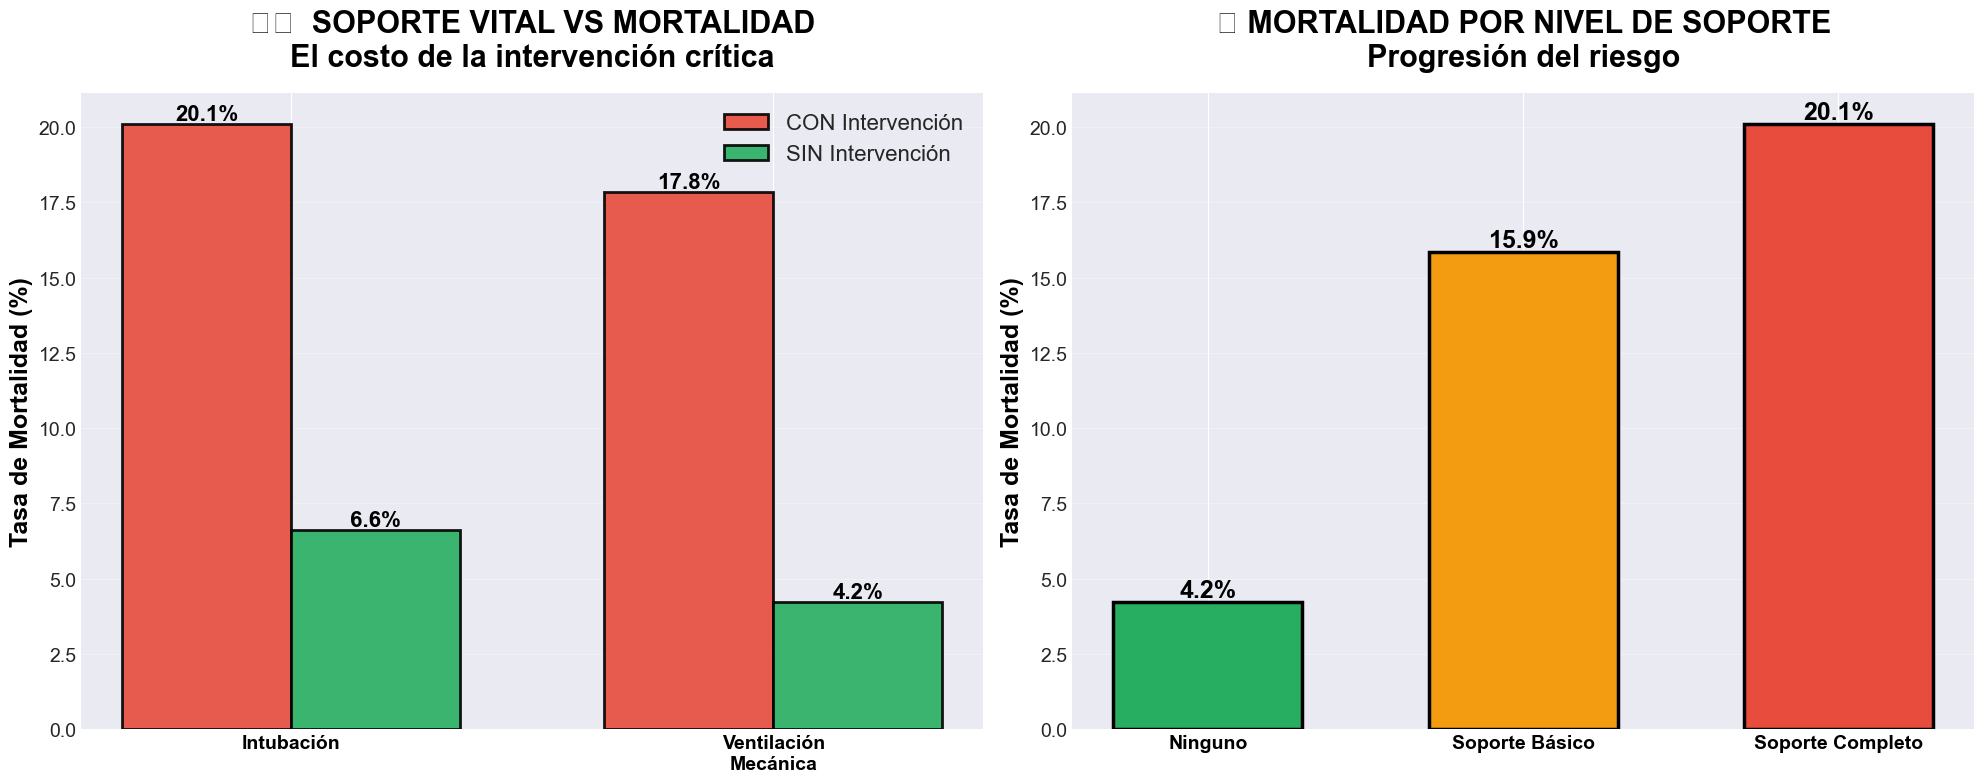

In [6]:
# VISUALIZACIÓN: SOPORTE VITAL VS MORTALIDAD
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('white')

# Gráfico 1: Comparación intubación y ventilación
ax1 = axes[0]
interventions = ['Intubación', 'Ventilación\nMecánica']
with_intervention = [intubated_mortality, ventilated_mortality]
without_intervention = [not_intubated_mortality, not_ventilated_mortality]

x_pos = np.arange(len(interventions))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, with_intervention, width, 
                label='CON Intervención', color='#e74c3c', alpha=0.9, edgecolor='black', linewidth=2)
bars2 = ax1.bar(x_pos + width/2, without_intervention, width, 
                label='SIN Intervención', color='#27ae60', alpha=0.9, edgecolor='black', linewidth=2)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(interventions, fontsize=18, weight='bold', color='black')
ax1.set_ylabel('Tasa de Mortalidad (%)', fontsize=18, weight='bold', color='black')
ax1.set_title('⚕️  SOPORTE VITAL VS MORTALIDAD\nEl costo de la intervención crítica', 
              fontsize=22, weight='bold', pad=20, color='black')
ax1.legend(fontsize=16, loc='upper right')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(labelsize=14)

# Añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}%', ha='center', va='bottom', 
                 fontsize=16, weight='bold', color='black')

# Gráfico 2: Niveles de soporte vital
ax2 = axes[1]
support_order = ['Ninguno', 'Soporte Básico', 'Soporte Completo']
support_analysis_sorted = support_analysis.set_index('vida_support_level').reindex(support_order).reset_index()
colors_support = ['#27ae60', '#f39c12', '#e74c3c']

bars3 = ax2.bar(range(len(support_analysis_sorted)), support_analysis_sorted['porcentaje'], 
                color=colors_support, edgecolor='black', linewidth=2.5, width=0.6)

ax2.set_xticks(range(len(support_analysis_sorted)))
ax2.set_xticklabels(support_analysis_sorted['vida_support_level'], 
                    fontsize=16, weight='bold', color='black')
ax2.set_ylabel('Tasa de Mortalidad (%)', fontsize=18, weight='bold', color='black')
ax2.set_title('📊 MORTALIDAD POR NIVEL DE SOPORTE\nProgresión del riesgo', 
              fontsize=22, weight='bold', pad=20, color='black')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(labelsize=14)

# Añadir valores en las barras
for i, bar in enumerate(bars3):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', 
             fontsize=18, weight='bold', color='black')

plt.tight_layout()
plt.show()

In [7]:
# MOSTRAR CONCLUSIÓN DEL HALLAZGO 5
display(HTML(f"""
<div style='background: white; padding: 40px; border-radius: 15px; margin: 30px 0; box-shadow: 0 5px 15px rgba(0,0,0,0.1);'>
    <div style='background: #d4edda; padding: 30px; border-radius: 12px; border-left: 6px solid #28a745;'>
        <h4 style='color: #000; font-size: 26px; margin: 0 0 15px 0; font-weight: bold;'>💡 CONCLUSIÓN HALLAZGO #5</h4>
        
        <div style='display: grid; grid-template-columns: repeat(2, 1fr); gap: 25px; margin: 25px 0;'>
            <div style='background: #fff3cd; padding: 25px; border-radius: 10px; border-left: 5px solid #e74c3c;'>
                <h5 style='color: #000; font-size: 22px; margin: 0 0 15px 0; font-weight: bold;'>🔴 INTUBACIÓN ENDOTRAQUEAL</h5>
                <div style='font-size: 18px; color: #000; line-height: 2;'>
                    <div><strong>CON intubación:</strong> {intubated_mortality:.1f}%</div>
                    <div><strong>SIN intubación:</strong> {not_intubated_mortality:.1f}%</div>
                    <div style='margin-top: 10px; color: #e74c3c; font-weight: bold;'>Factor: {intubation_risk_factor:.2f}x mayor riesgo</div>
                </div>
            </div>
            <div style='background: #fff3cd; padding: 25px; border-radius: 10px; border-left: 5px solid #e74c3c;'>
                <h5 style='color: #000; font-size: 22px; margin: 0 0 15px 0; font-weight: bold;'>🔴 VENTILACIÓN MECÁNICA</h5>
                <div style='font-size: 18px; color: #000; line-height: 2;'>
                    <div><strong>CON ventilación:</strong> {ventilated_mortality:.1f}%</div>
                    <div><strong>SIN ventilación:</strong> {not_ventilated_mortality:.1f}%</div>
                    <div style='margin-top: 10px; color: #e74c3c; font-weight: bold;'>Factor: {ventilation_risk_factor:.2f}x mayor riesgo</div>
                </div>
            </div>
        </div>
        
        <p style='font-size: 20px; line-height: 1.8; color: #000; margin: 20px 0 0 0;'>
            <strong>Implicación clínica:</strong> Aunque la intubación y ventilación mecánica son medidas 
            para <strong>salvar vidas</strong>, su necesidad es un marcador de gravedad extrema. Los pacientes 
            que requieren soporte vital tienen un riesgo significativamente mayor y deben ser priorizados 
            para monitoreo continuo y cuidados intensivos.
        </p>
        
        <div style='background: #e3f2fd; padding: 20px; border-radius: 10px; margin-top: 20px; border-left: 5px solid #3498db;'>
            <p style='font-size: 18px; color: #000; margin: 0;'>
                <strong>⚠️  Nota importante:</strong> La mortalidad alta NO significa que la intervención sea mala. 
                Al contrario, estas intervenciones <strong>salvan vidas</strong>. La alta mortalidad refleja la 
                <strong>gravedad de los pacientes</strong> que necesitan estos soportes, no la efectividad del tratamiento.
            </p>
        </div>
    </div>
</div>
"""))

## 🎓 CONTINUARÁ CON LOS 3 HALLAZGOS FINALES...

**Ya cubierto:**
- ✅ HALLAZGO #4: Glasgow <8 = Mortalidad >70%
- ✅ HALLAZGO #5: Soporte Vital = Bandera Roja

**Faltan:**
- ⏳ HALLAZGO #6: Comorbilidades (efecto multiplicador)
- ⏳ HALLAZGO #7: Primera hora vs primer día
- ⏳ HALLAZGO #8: Modelo vs APACHE